# Domain-Specific Text Analysis and Retrieval System
### Learner language about school mathematics — NLP Assessment-1, Vidyashilp University

**Research context.** The wider project is *language-grounded learner state modelling for misconception-aware adaptive
learning*: a tutor should read what a learner writes ("I added the tops and the bottoms"), connect it to concept and
misconception documents, and use that as evidence about what the learner believes. This assessment builds the text
front end of that loop: corpus construction, cleaning, tokenization, linguistic analysis, a positional inverted index,
Boolean and phrase retrieval, and evaluation. It builds **no** learner model; the last section only previews the
evidence record the research phase will consume.

**How the notebook is organised.** Sections follow the brief: Module 1 (corpus), Module 2 (Exercises 1–14), Module 3
(pipeline design and justification), Module 4 (inverted index), Module 5 (query processing), Module 6 (evaluation).
Each step follows the brief's loop — *select, order, implement, compare, evaluate, justify* — and each design decision
answers four questions: why the step is needed, where it sits, what it depends on and what happens if it moves.

**Where the code lives.** Reusable code is in the `nlp_core` package next to this notebook; the notebook calls it,
shows intermediate results, and writes every results table to `results/`. The same package powers the website
(`api/` FastAPI + `web/` React), so the numbers in the notebook, the CSV files and the website are identical.

**Honesty notes.** Six documents (D25–D30) are synthetic and labelled as such. Relevance judgements (`gold/qrels.csv`)
were drafted with an AI assistant and must be reviewed by the student; a template for a second judge is provided.
Gold sets are small (40 tokenization sentences, 32 POS sentences, 61 NER sentences, 15 queries), so differences of a
point or two are within noise and are described that way.

In [1]:
# Setup. Run from the project folder (the one that contains nlp_core/ and data/).
# In Colab: upload or mount the project folder, set DATA_SOURCE = "drive" and DRIVE_PATH below.
import os, sys, json, time, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ.setdefault("NLTK_ALLOW_PROXIED_URLOPEN", "1")

ROOT = Path.cwd() if (Path.cwd() / "nlp_core").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

DATA_SOURCE = "local"   # "local" or "drive"
DRIVE_PATH = "/content/drive/MyDrive/Domain_Text_Analysis_Retrieval/data"

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from nlp_core.config import resolve_data_dir, RESULTS, GOLD
from nlp_core import experiments as X
DATA_DIR = resolve_data_dir(DATA_SOURCE, DRIVE_PATH)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
# One fixed colour per pipeline across every chart (colour follows the entity, never its rank).
RUN_COLOR = {"A": "#2a78d6", "B": "#eb6834", "H": "#1baf7a", "C1": "#eda100", "C2": "#e87ba4", "C3": "#008300", "H2": "#4a3aa7"}
LAYER_COLOR = {"concept": "#2a78d6", "research": "#eb6834", "learner": "#1baf7a", "synthetic": "#eda100"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e6e4df", "grid.linewidth": 0.6, "font.size": 10})
def table(rows, cols=None, n=None):
    df = pd.DataFrame(rows)
    if cols: df = df[cols]
    return df.head(n) if n else df

import spacy, nltk, sklearn, tiktoken
print("data folder:", DATA_DIR, "| documents:", len(list(DATA_DIR.glob("D*"))))
print("spaCy", spacy.__version__, "| NLTK", nltk.__version__, "| scikit-learn", sklearn.__version__, "| tiktoken", tiktoken.__version__)

data folder: /home/claude/Domain_Text_Analysis_Retrieval/data | documents: 30
spaCy 3.8.16 | NLTK 3.10.3 | scikit-learn 1.8.0 | tiktoken 0.14.0


---
## Module 1 — Corpus construction and cleaning

**Selection.** The corpus has four layers so that a learner's words can be connected to the knowledge they are about
and to the research that names their misconceptions:

| Layer | Documents | Source (licence) |
|---|---|---|
| Concept knowledge | D01–D08 | OpenStax *Prealgebra 2e*, fractions, decimals, ratios, percents — CNXML with MathML (CC BY-NC-SA 4.0) |
| Research | D09–D15 | ACL Anthology 2022–2025 abstracts on knowledge tracing and tutoring (CC BY 4.0); TalkMoves coding manual (PDF); MathDial and MaE dataset cards (Markdown) |
| Learner language | D16–D24 | MaE misconceptions JSON (55 misconceptions, 220 examples); MathDial tutoring dialogues (JSONL, CSV); six TalkMoves lesson transcripts (XLSX) |
| Synthetic learner artefacts | D25–D30 | Written for this project to cover formats the public data lacks: explanations (TXT), questions (TXT), teacher notes (DOCX), tutor chat (JSON), class web page (HTML), worksheet (PDF) — each line labelled with its misconception |

Thirty documents in ten file formats: XML, PDF, Markdown, JSON, JSONL, CSV, XLSX, TXT, DOCX and HTML.

In [2]:
from nlp_core.loaders import read_catalog, load_corpus
catalog = pd.DataFrame(read_catalog())
display(catalog[["doc_id", "title", "format", "layer", "source", "licence", "synthetic"]])
print(catalog.groupby("layer").size().to_dict(), "| file formats:", catalog["format"].str.split(" ").str[0].nunique())

,doc_id,title,format,layer,source,licence,synthetic
0,D01,"OpenStax Prealgebra 2e, section 4.1 Visualize Fractions",XML (CNXML + MathML),concept,openstax,CC BY-NC-SA 4.0,False
1,D02,"OpenStax Prealgebra 2e, section 4.2 Multiply and Divide Fractions",XML (CNXML + MathML),concept,openstax,CC BY-NC-SA 4.0,False
2,D03,"OpenStax Prealgebra 2e, section 4.4 Add and Subtract Fractions with Common Denominators",XML (CNXML + MathML),concept,openstax,CC BY-NC-SA 4.0,False
3,D04,"OpenStax Prealgebra 2e, section 4.5 Add and Subtract Fractions with Different Denominators",XML (CNXML + MathML),concept,openstax,CC BY-NC-SA 4.0,False
4,D05,"OpenStax Prealgebra 2e, section 5.1 Decimals",XML (CNXML + MathML),concept,openstax,CC BY-NC-SA 4.0,False
5,D06,"OpenStax Prealgebra 2e, section 5.3 Decimals and Fractions",XML (CNXML + MathML),concept,openstax,CC BY-NC-SA 4.0,False
6,D07,"OpenStax Prealgebra 2e, section 5.6 Ratios and Rate",XML (CNXML + MathML),concept,openstax,CC BY-NC-SA 4.0,False
7,D08,"OpenStax Prealgebra 2e, section 6.1 Understand Percent",XML (CNXML + MathML),concept,openstax,CC BY-NC-SA 4.0,False
8,D09,"ACL 2025: knowledge tracing, tutoring and education papers (incl. SQKT)",XML (ACL Anthology),research,acl,CC BY 4.0 (ACL Anthology metadata),False
9,D10,EMNLP 2025: knowledge tracing and education papers (incl. CIKT),XML (ACL Anthology),research,acl,CC BY 4.0 (ACL Anthology metadata),False


{'concept': 8, 'learner': 9, 'research': 7, 'synthetic': 6} | file formats: 10


### 1.1 Loading every format

Each format has its own loader. The important decisions are what to *keep out* of the text: OpenStax image alt texts
(they describe pictures, not mathematics), MathDial dialogue-act labels such as `(probing)` and TalkMoves talk-move codes
are moved into metadata so that the index holds only what was said. MathML is linearised (`<mfrac>3 4</mfrac>` → `3/4`).

In [3]:
corpus = load_corpus(DATA_DIR)
for d in corpus[:1] + [corpus[16], corpus[18], corpus[27]]:
    print(f"--- {d.doc_id} [{d.fmt}] {d.title}\n{d.text[:420]}\n")
print({d.doc_id: {k: v for k, v in d.meta.items() if k in ('loader', 'alt_texts_removed', 'dialogues', 'rows')} for d in corpus[:3]})

--- D01 [XML] OpenStax Prealgebra 2e, section 4.1 Visualize Fractions
Visualize Fractions

By the end of this section, you will be able to:



Understand the meaning of fractions


Model improper fractions and mixed numbers


Convert between improper fractions and mixed numbers


Model equivalent fractions


Find equivalent fractions


Locate fractions and mixed numbers on the number line


Order fractions and mixed numbers



  



Before you get started, take this readiness quiz.





--- D17 [JSONL] MathDial: 60 tutoring dialogues on fraction, ratio and percent problems (test split)
Problem: Karan borrowed $3,650 for five months at an interest rate of 10%. She has to pay an equal amount every month. How much does she have to pay per month?
Profile: Scott is a 7th grade student. He struggle to put the numbers in the correct order in the equation or determine the correct operation to use.
Incorrect solution: Karan borrowed $3,650 for 5 months, so the total interest she has to pay is 3

### 1.2 Choosing an extractor

PDF and HTML extraction quality varies most, so two extractors were compared for each. For PDFs the measure is the
share of extracted words found in a dictionary (broken words such as "T alk Mo ves" lower it); for HTML it is the number
of navigation, cookie and footer phrases that leak into the text.

In [4]:
from nlp_core.loaders import compare_pdf_extractors, compare_html_extractors
pdf = compare_pdf_extractors(next(DATA_DIR.glob("D13_*")))
html = compare_html_extractors(next(DATA_DIR.glob("D29_*")))
display(table(pdf, ["method", "pages", "words", "dictionary_word_share", "seconds"]))
display(table(html, ["method", "words", "boilerplate_phrases_found"]))

,method,pages,words,dictionary_word_share,seconds
0,pypdf,11,3021,0.6948,0.261
1,pdfplumber,11,2260,0.8327,0.984


,method,words,boilerplate_phrases_found
0,trafilatura,290,0
1,beautifulsoup,333,7


pdfplumber keeps D13's words whole and trafilatura drops the page chrome, so both are the loaders' defaults.

### 1.3 Cleaning

Cleaning is an ordered list of steps, each logged per document: vulgar fractions → Unicode NFKC → typography →
de-hyphenation → reference sections → URLs → emoji → table markup → page numbers → digit-word glue → whitespace.

In [5]:
from nlp_core.cleaning import clean_text, split_sentences
for s in ["He ate 3½ pizzas.", "the denomi-\nnator is 8", "cut into 1/8pieces", "see https://example.org/page for more"]:
    c, log = clean_text(s, "TXT")
    print(f"{s!r:45} -> {c!r:32} {[k for k, v in log.items() if v]}")
import unicodedata
print("NFKC first would give:", repr(unicodedata.normalize("NFKC", "3½")), "- a different number, so vulgar fractions go first")

'He ate 3½ pizzas.'                           -> 'He ate 3 1/2 pizzas.'           ['vulgar_fractions']
'the denomi-\nnator is 8'                     -> 'the denominator is 8'           ['dehyphenate']
'cut into 1/8pieces'                          -> 'cut into 1/8 pieces'            ['digit_word_glue']
'see https://example.org/page for more'       -> 'see for more'                   ['urls', 'whitespace']
NFKC first would give: '31⁄2' - a different number, so vulgar fractions go first


> **Why this step.** Tokenizers and indexes see whatever the loader hands them; markup, page numbers, hyphenated line breaks, vulgar fractions and URLs would each become tokens or break real ones.
>
> **Where it sits.** Straight after extraction and before sentence splitting, so every later module reads the same cleaned text.
>
> **What it depends on.** The right extractor per format (pdfplumber, trafilatura, MathML linearisation).
>
> **If its position changes.** Cleaning after tokenization leaves '3½' and '1/8pieces' as single wrong tokens; NFKC before the vulgar-fraction step turns '3½' into '31⁄2'.

### 1.4 Corpus statistics

In [6]:
m1 = X.module1()
display(pd.DataFrame([m1["summary"]]))
docs = pd.DataFrame(m1["documents"])
display(docs[["doc_id", "format", "layer", "sentences", "tokens", "word_tokens", "vocabulary", "type_token_ratio", "hapax"]])
display(pd.DataFrame(m1["cleaning"]).set_index("doc_id").loc[:, lambda d: d.sum() > 0])

,documents,sentences,tokens,word_tokens,characters,avg_doc_length_tokens,avg_doc_length_characters,vocabulary
0,30,13706,163765,135107,807942,5458.8,26931.4,10741


,doc_id,format,layer,sentences,tokens,word_tokens,vocabulary,type_token_ratio,hapax
0,D01,XML (CNXML + MathML),concept,618,5498,4777,739,0.1547,355
1,D02,XML (CNXML + MathML),concept,722,4164,3344,775,0.2318,418
2,D03,XML (CNXML + MathML),concept,336,2029,1605,510,0.3178,296
3,D04,XML (CNXML + MathML),concept,724,4662,3705,811,0.2189,482
4,D05,XML (CNXML + MathML),concept,688,5216,4539,804,0.1771,438
5,D06,XML (CNXML + MathML),concept,496,2936,2413,679,0.2814,426
6,D07,XML (CNXML + MathML),concept,549,4487,3828,862,0.2252,454
7,D08,XML (CNXML + MathML),concept,692,4068,3462,835,0.2412,500
8,D09,XML (ACL Anthology),research,308,7200,6031,1914,0.3174,1151
9,D10,XML (ACL Anthology),research,297,7383,6196,2015,0.3252,1224


,vulgar_fractions,unicode_nfkc,typography,references,urls,emoji,table_markup,page_numbers,digit_word_glue,whitespace
doc_id,,,,,,,,,,
D01,0,970,62,0,0,0,0,0,0,2960
D02,0,44,42,0,0,4,0,0,1,4383
D03,0,2,23,0,0,0,0,0,3,2208
D04,0,86,33,0,0,0,0,0,0,4615
D05,0,16804,157,0,0,0,0,0,0,3381
D06,0,13209,58,0,0,0,0,0,0,2651
D07,0,8646,11,0,0,0,0,0,0,2658
D08,0,7670,19,0,1,0,0,0,0,3804
D09,0,0,45,0,4,0,0,0,0,9


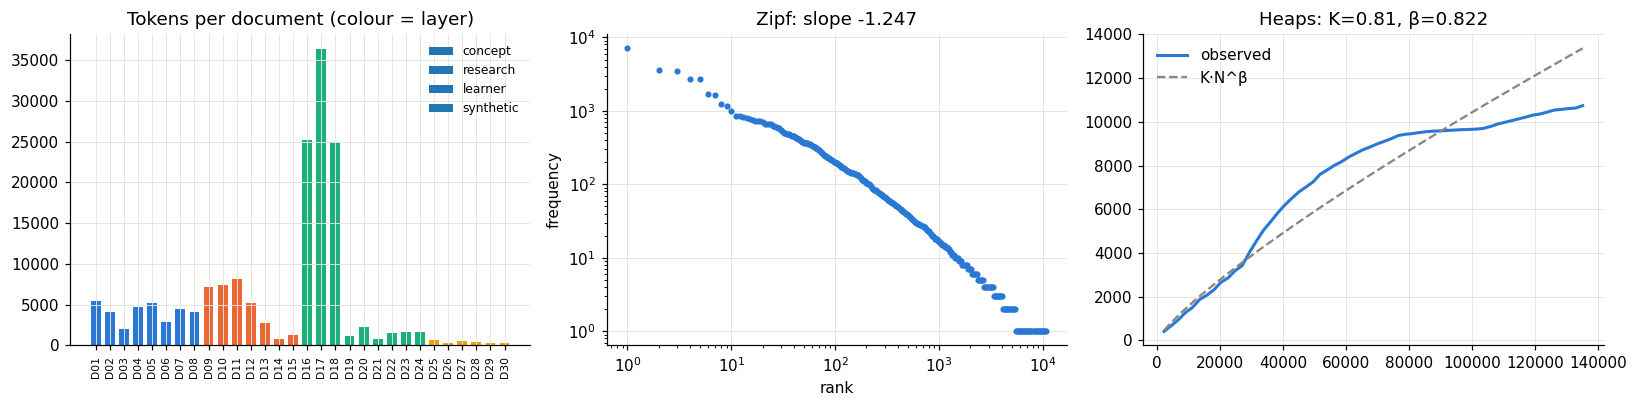

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].bar(docs.doc_id, docs.tokens, color=[LAYER_COLOR[l] for l in docs.layer], width=0.7)
ax[0].set_title("Tokens per document (colour = layer)"); ax[0].tick_params(axis="x", rotation=90, labelsize=7)
for l, c in LAYER_COLOR.items(): ax[0].bar([], [], color=c, label=l)
ax[0].legend(frameon=False, fontsize=8)
z = pd.DataFrame(m1["zipf"]["points"]); ax[1].loglog(z["rank"], z["freq"], "o", ms=3, color="#2a78d6")
ax[1].set_title(f"Zipf: slope {m1['zipf']['slope']}"); ax[1].set_xlabel("rank"); ax[1].set_ylabel("frequency")
h = pd.DataFrame(m1["heaps"]["points"]); ax[2].plot(h.tokens, h.vocabulary, color="#2a78d6", lw=2, label="observed")
ax[2].plot(h.tokens, m1["heaps"]["K"] * h.tokens ** m1["heaps"]["beta"], color="#8a877f", lw=1.5, ls="--", label="K·N^β")
ax[2].set_title(f"Heaps: K={m1['heaps']['K']}, β={m1['heaps']['beta']}"); ax[2].legend(frameon=False)
plt.tight_layout(); plt.show()

Both laws hold, which is a sanity check that cleaning did not distort the text. β ≈ 0.82 is high: fractions like
"240/4" and ratios like "3:5" are types the hybrid tokenizer keeps whole, and most of them occur once.

---
## Module 2 — Text processing and linguistic analysis

Several exercises report numbers "for the final pipeline", which is only known after Module 3 compares the pipelines.
To keep the brief's order, all seven pipeline runs are built once here (each is cached on disk) and the selection is
computed quietly; Module 3 then presents and justifies it. The selection rule was fixed before any run:
**highest mean F1 over the 15 gold queries, then P@5, then domain-term fidelity, then the smaller vocabulary**, with the
post-hoc pipeline H2 excluded.

In [8]:
from nlp_core.pipelines import Pipeline, all_run_names
from nlp_core.preprocess import write_custom_stopwords
write_custom_stopwords()
runs = {}
for n in all_run_names():
    t = time.time(); runs[n] = Pipeline.from_config(n).run()
    s = runs[n].summary()
    print(f"{n:3} {s['label']:32} tokens={s['token_count']:>7,}  vocabulary={s['vocabulary_size']:>6,}  ({time.time() - t:.1f}s)")
ir = X.modules3_6(runs)          # Module 3-6 results, explained below
FINAL = ir["winner"]
print("selected pipeline:", FINAL)

A   Pipeline A                       tokens= 85,104  vocabulary= 8,549  (2.9s)


B   Pipeline B                       tokens=136,273  vocabulary= 8,931  (1.2s)


H   H: hybrid hypothesis             tokens= 86,519  vocabulary= 9,456  (1.2s)


C1  C1 order test                    tokens= 87,633  vocabulary= 8,559  (0.8s)


C2  C2 no-POS lemma                  tokens=136,273  vocabulary= 9,495  (1.3s)


C3  C3 BPE index                     tokens=156,313  vocabulary= 7,748  (1.5s)


H2  H2: hybrid, revised (post-hoc)   tokens= 89,044  vocabulary= 9,454  (4.4s)


selected pipeline: B


### Exercise 1 — Preprocessing before and after (Table A)

Table A compares the raw extracted text (NLTK word tokens before cleaning) with the index terms of the final pipeline.

In [9]:
pre = X.preprocessing(runs, FINAL)
display(table(pre["table_a"]))
display(table(pre["stages"]))

,measure,before,after
0,Documents,30,30
1,Tokens,164513,136273
2,Unique tokens,12106,8931
3,Vocabulary size (lower-cased word types),10820,8931
4,Characters,837474,807942


,stage,tokens,dictionary_size
0,tokenized,165568,11504
1,lowercased,165568,10280
2,stopwords_removed,165568,10280
3,normalized,165568,8975
4,index_terms,136273,8931


### Exercise 2 — Tokenization on the corpus

Four tokenizers are compared as the brief asks (NLTK, spaCy, a custom rule tokenizer, a hybrid), plus four NLTK and
whitespace variants as reference points. The **custom** tokenizer is an ordered regex alternation of 14 protected
patterns (URLs and emails, ISO dates and times, currency with its symbol, mixed numbers, arithmetic expressions,
fractions, percents, ratios, numbers, ordinals, abbreviations, hyphenated compounds, alphanumerics, informal forms).
The **hybrid** keeps spaCy's tokenizer and exception handling but removes its letter-hyphen-letter infix and merges
the protected spans, so POS tagging, lemmas and NER run on the same tokens.

In [10]:
from nlp_core import tokenizers as T
demo = "I did 1/2+1/3=2/5, idk why; 3 1/2 cups cost $3,650 (a 46% rise) on 2026-09-01 in an LLM-based test."
for name in ["whitespace", "nltk", "spacy", "custom", "hybrid"]:
    print(f"{name:10} {T.tokenize(demo, name)}")
tok = X.exercise2_3_6()
display(table(tok["corpus"]))
display(table(tok["audit"]))

whitespace ['I', 'did', '1/2+1/3=2/5,', 'idk', 'why;', '3', '1/2', 'cups', 'cost', '$3,650', '(a', '46%', 'rise)', 'on', '2026-09-01', 'in', 'an', 'LLM-based', 'test.']
nltk       ['I', 'did', '1/2+1/3=2/5', ',', 'idk', 'why', ';', '3', '1/2', 'cups', 'cost', '$', '3,650', '(', 'a', '46', '%', 'rise', ')', 'on', '2026-09-01', 'in', 'an', 'LLM-based', 'test', '.']
spacy      ['I', 'did', '1/2', '+', '1/3=2/5', ',', 'idk', 'why', ';', '3', '1/2', 'cups', 'cost', '$', '3,650', '(', 'a', '46', '%', 'rise', ')', 'on', '2026', '-', '09', '-', '01', 'in', 'an', 'LLM', '-', 'based', 'test', '.']
custom     ['I', 'did', '1/2+1/3=2/5', ',', 'idk', 'why', ';', '3 1/2', 'cups', 'cost', '$3,650', '(', 'a', '46%', 'rise', ')', 'on', '2026-09-01', 'in', 'an', 'LLM-based', 'test', '.']
hybrid     ['I', 'did', '1/2+1/3=2/5', ',', 'idk', 'why', ';', '3 1/2', 'cups', 'cost', '$3,650', '(', 'a', '46%', 'rise', ')', 'on', '2026-09-01', 'in', 'an', 'LLM-based', 'test', '.']


,tokenizer,label,tokens,dictionary_size,dictionary_lowercased,punctuation_tokens
0,whitespace,Whitespace,135634,17110,15874,2394
1,nltk,NLTK word_tokenize,163796,11996,10783,28689
2,nltk_wordpunct,NLTK wordpunct,182358,9254,8015,38126
3,nltk_treebank,NLTK Treebank,163617,12044,10833,28580
4,nltk_tweet,NLTK Tweet,168411,10941,9709,31331
5,spacy,spaCy,165568,11504,10280,29295
6,custom,Custom (regex rules),164601,11673,10439,29357
7,hybrid,Hybrid (spaCy + rules),159870,12284,11058,26186


,tokenizer,problem,occurrences,examples,fix
0,nltk,fraction split,1,12 / 8,custom rule `fraction`
1,nltk,hyphenated word split,94,fifths - one | no - I | pieces - meaning,remove spaCy hyphen infix; rule `compound`
2,nltk,currency symbol split,1479,costs $ 3.45 | costs $ 1.25 | is $ 0.33,rule `currency`
3,nltk,percent split,608,"57 % of | 25 % means | 25/100,3 % means",rule `percent`
4,nltk,abbreviation broken,11,", etc . | , etc . | , etc .",rule `abbreviation`
5,nltk,contraction split,796,That 's right | Let 's think | you 're right,rule `compound` / `informal`
6,nltk,operator split from expression,943,24 + 5 | 2^9 = 2+2+2+2+2+2+2+2+2=18 | 5/6 = 1,rule `expression`
7,nltk,case duplicates in dictionary,1197,Fraction / fraction,lowercase on the index branch only (after NER)
8,spacy,fraction split,1,12 / 8,custom rule `fraction`
9,spacy,hyphenated word split,1075,twenty - fourths | twenty - fourths | three - fifths,remove spaCy hyphen infix; rule `compound`


### Exercise 3 — Scoring against hand-segmented gold (Table B)

Forty sentences (651 gold tokens) were chosen for the hard cases and tagged with a problem type. Scores are token-level
precision, recall and F1 over exact spans. Custom and hybrid share the rules, so the gold spans — written with those
rules in mind — favour them; the fair comparison is on hyphenated terms, acronyms and informal text.

In [11]:
display(table(tok["scores"], ["label", "precision", "recall", "f1", "sentence_exact_match"] + [c for c in tok["scores"][0] if c.startswith("f1_")]))
display(table(tok["ablation"]))
display(table(tok["table_b"]))

,label,precision,recall,f1,sentence_exact_match,f1_acronym,f1_currency_percent,f1_decimal_ratio_date,f1_expression,f1_fraction,f1_hyphenated,f1_informal,f1_mixed_number
0,Whitespace,0.8147,0.6959,0.7506,0.025,0.7651,0.7353,0.7673,0.7578,0.8205,0.8092,0.6901,0.6706
1,NLTK word_tokenize,0.9358,0.9631,0.9493,0.600,0.9816,0.8462,0.9827,0.9663,1.0000,0.9677,1.0000,0.8634
2,NLTK wordpunct,0.6838,0.8802,0.7696,0.100,0.8588,0.6821,0.7576,0.6944,0.7465,0.8400,0.8721,0.7204
3,NLTK Treebank,0.9339,0.9555,0.9446,0.600,1.0000,0.8462,0.9651,0.9492,1.0000,0.9677,1.0000,0.8462
4,NLTK Tweet,0.8706,0.9401,0.9040,0.425,0.8889,0.8280,0.9379,0.7897,1.0000,1.0000,0.9689,0.8541
5,spaCy,0.8569,0.9293,0.8917,0.325,0.9518,0.8050,0.9492,0.8525,0.9683,0.8485,0.9448,0.8432
6,Custom (regex rules),0.9863,0.9939,0.9901,0.950,0.9756,1.0000,1.0000,0.9497,1.0000,1.0000,1.0000,1.0000
7,Hybrid (spaCy + rules),0.9985,0.9939,0.9962,0.975,1.0000,1.0000,1.0000,0.9711,1.0000,1.0000,1.0000,1.0000


,rule_removed,f1,f1_drop
0,url_email,0.9962,0.0000
1,datetime,0.9900,0.0062
2,currency,0.9824,0.0138
3,mixed_number,0.9801,0.0161
4,expression,0.9900,0.0062
5,fraction,0.9962,0.0000
6,percent,0.9847,0.0115
7,ratio_time,0.9962,0.0000
8,number,0.9962,0.0000
9,ordinal,0.9962,0.0000


,id,problem_type,input,nltk,spacy,custom,hybrid,gold
0,T10,expression,I did 1/2+1/3=2/5 because you add the tops and then add the bottoms.,I | did | 1/2+1/3=2/5 | because | you | add | the | tops | and | then | add | the | bottoms | .,I | did | 1/2 | + | 1/3=2/5 | because | you | add | the | tops | and | then | add | the | bottoms | .,I | did | 1/2+1/3=2/5 | because | you | add | the | tops | and | then | add | the | bottoms | .,I | did | 1/2+1/3=2/5 | because | you | add | the | tops | and | then | add | the | bottoms | .,I | did | 1/2+1/3=2/5 | because | you | add | the | tops | and | then | add | the | bottoms | .
1,T13,mixed_number,"The fraction 8/5 is one whole, 1, plus three fifths, 3/5, or 1 3/5, which is read as one and three-fifths.","The | fraction | 8/5 | is | one | whole | , | 1 | , | plus | three | fifths | , | 3/5 | , | or | 1 | 3/5 | , | which...","The | fraction | 8/5 | is | one | whole | , | 1 | , | plus | three | fifths | , | 3/5 | , | or | 1 | 3/5 | , | which...","The | fraction | 8/5 | is | one | whole | , | 1 | , | plus | three | fifths | , | 3/5 | , | or | 1 3/5 | , | which |...","The | fraction | 8/5 | is | one | whole | , | 1 | , | plus | three | fifths | , | 3/5 | , | or | 1 3/5 | , | which |...","The | fraction | 8/5 | is | one | whole | , | 1 | , | plus | three | fifths | , | 3/5 | , | or | 1 3/5 | , | which |..."
2,T16,mixed_number,A recipe needs 2 1/4 cups of flour. Meera has 1 1/2 cups.,A | recipe | needs | 2 | 1/4 | cups | of | flour | . | Meera | has | 1 | 1/2 | cups | .,A | recipe | needs | 2 | 1/4 | cups | of | flour | . | Meera | has | 1 | 1/2 | cups | .,A | recipe | needs | 2 1/4 | cups | of | flour | . | Meera | has | 1 1/2 | cups | .,A | recipe | needs | 2 1/4 | cups | of | flour | . | Meera | has | 1 1/2 | cups | .,A | recipe | needs | 2 1/4 | cups | of | flour | . | Meera | has | 1 1/2 | cups | .
3,T21,hyphenated,"Our system is built on MPNet, a Transformer-based language model that combines BERT and XLNet's pre-training advanta...","Our | system | is | built | on | MPNet | , | a | Transformer-based | language | model | that | combines | BERT | and...","Our | system | is | built | on | MPNet | , | a | Transformer | - | based | language | model | that | combines | BERT...","Our | system | is | built | on | MPNet | , | a | Transformer-based | language | model | that | combines | BERT | and...","Our | system | is | built | on | MPNet | , | a | Transformer-based | language | model | that | combines | BERT | and...","Our | system | is | built | on | MPNet | , | a | Transformer-based | language | model | that | combines | BERT | and..."
4,T26,acronym,"Models like Q-MCKT are evaluated on ASSIST2009, e.g. by a B.Tech student.","Models | like | Q-MCKT | are | evaluated | on | ASSIST2009 | , | e.g | . | by | a | B.Tech | student | .","Models | like | Q | - | MCKT | are | evaluated | on | ASSIST2009 | , | e.g. | by | a | B.Tech | student | .","Models | like | Q-MCKT | are | evaluated | on | ASSIST2009 | , | e.g. | by | a | B.Tech | student | .","Models | like | Q-MCKT | are | evaluated | on | ASSIST2009 | , | e.g. | by | a | B.Tech | student | .","Models | like | Q-MCKT | are | evaluated | on | ASSIST2009 | , | e.g. | by | a | B.Tech | student | ."
5,T28,currency_percent,"So, her annual pension after 30 years would be $50,000 + ($50,000 x 50%) = $75,000.","So | , | her | annual | pension | after | 30 | years | would | be | $ | 50,000 | + | ( | $ | 50,000 | x | 50 | % | )...","So | , | her | annual | pension | after | 30 | years | would | be | $ | 50,000 | + | ( | $ | 50,000 | x | 50 | % | )...","So | , | her | annual | pension | after | 30 | years | would | be | $50,000 | + | ( | $50,000 | x | 50% | ) | = | $7...","So | , | her | annual | pension | after | 30 | years | would | be | $50,000 | + | ( | $50,000 | x | 50% | ) | = | $7...","So | , | her | annual | pension | after | 30 | years | would | be | $50,000 | + | ( | $50,000 | x | 50% | ) | = | $7..."
6,T31,currency_percent,"A cricket bat costs R

Removing a rule from the hybrid tokenizer and re-scoring shows which rules earn their place. Seven show no drop: spaCy
already keeps a lone 1/2, 3:5 or 1st whole, and URLs are not in the gold set; they stay because the standalone custom
tokenizer needs them.

> **Why this step.** Every later stage counts tokens: if 1/2 becomes three tokens the index cannot find the fraction, the POS tagger sees a symbol between numbers and NER cannot see a money amount.
>
> **Where it sits.** First step after cleaning and sentence splitting; the hybrid tokenizer runs inside spaCy.
>
> **What it depends on.** Cleaned text with vulgar fractions expanded and digit-word glue split.
>
> **If its position changes.** Tokenizing before cleaning keeps the glue errors. Protecting spans also changes NER: once $3,650 is one token spaCy's model stops tagging it, so the EntityRuler adds MONEY patterns (Exercise 13).

### Exercise 4 — Byte-pair encoding

BPE starts from characters and repeatedly merges the most frequent adjacent pair. Three OpenAI encodings (tiktoken
gpt2, cl100k_base, o200k_base; the rank files are converted from the `js-tiktoken` npm package because the usual download
host is not reachable here, and verified: gpt2 has 50,257 entries and "Hello" encodes to 15496) are compared with our own
BPE trained on this corpus with 500, 1,000 and 2,000 merges, and with a word-level `SimpleTokenizerV2` as in the lab.

gpt2 n_vocab 50257 | 'Hello' -> [15496]


,word,class,gpt2,cl100k_base,o200k_base,ours_500,ours_1000,ours_2000
0,teacher,common,▁teacher,▁teacher,▁teacher,teacher</w>,teacher</w>,teacher</w>
1,number,common,▁number,▁number,▁number,number</w>,number</w>,number</w>
2,student,common,▁student,▁student,▁student,student</w>,student</w>,student</w>
3,answer,common,▁answer,▁answer,▁answer,answer</w>,answer</w>,answer</w>
4,total,common,▁total,▁total,▁total,total</w>,total</w>,total</w>
5,fraction,common,▁fraction,▁fraction,▁fraction,fraction</w>,fraction</w>,fraction</w>
6,students,common,▁students,▁students,▁students,students</w>,students</w>,students</w>
7,incorrect,common,▁incorrect,▁incorrect,▁incorrect,incorrect</w>,incorrect</w>,incorrect</w>
8,problem,common,▁problem,▁problem,▁problem,problem</w>,problem</w>,problem</w>
9,solution,common,▁solution,▁solution,▁solution,solution</w>,solution</w>,solution</w>


,class,gpt2,cl100k_base,o200k_base,ours_500,ours_1000,ours_2000
0,common,1.0,1.0,1.0,1.0,1.0,1.0
1,rare,1.4,1.4,1.4,4.6,4.1,3.7
2,domain,3.6,3.4,3.4,3.9,3.2,2.6


,method,vocabulary_size,corpus_tokens,trained_on,oov_rate_unseen_text
0,tiktoken gpt2,50257,213228,OpenAI web data,0.0000
1,tiktoken cl100k_base,100277,205643,OpenAI web data,0.0000
2,tiktoken o200k_base,200019,203427,OpenAI web data,0.0000
3,our BPE 500 merges,537,277042,this corpus,0.0000
4,our BPE 1000 merges,1037,226013,this corpus,0.0000
5,our BPE 2000 merges,2037,187771,this corpus,0.0000
6,NLTK word_tokenize,11996,163796,rules / pretrained,NaN
7,spaCy,11504,165568,rules / pretrained,NaN
8,Custom (regex rules),11673,164601,rules / pretrained,NaN
9,Hybrid (spaCy + rules),12284,159870,rules / pretrained,NaN


first merges: ['e</w>', 's</w>', 'th', 't</w>', 'er', 'in', 'd</w>', 'on', 'an', 'en', 'the</w>', 'ti', 'or', 'o</w>', 'al']
SimpleTokenizerV2: {'text': 'The LCD of 4 and 6 is 12, obviously.', 'decoded': 'The LCD of 4 and 6 is 12, <|unk|>.'}


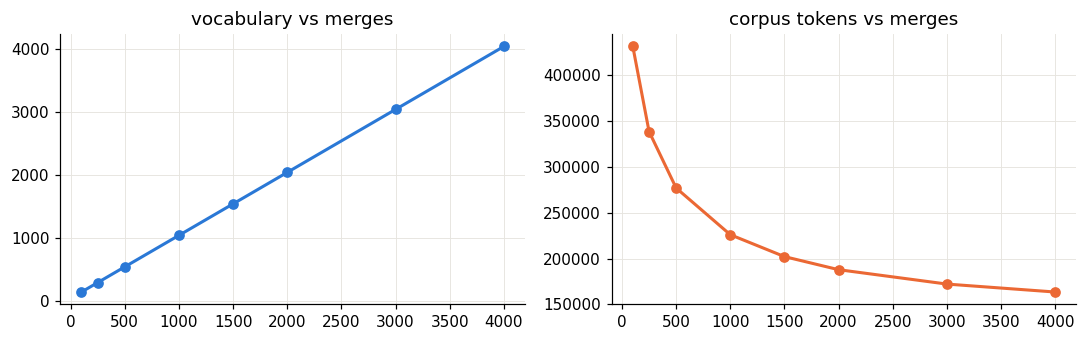

In [12]:
from nlp_core import bpe as B
enc = B.encoding("gpt2"); print("gpt2 n_vocab", enc.n_vocab, "| 'Hello' ->", enc.encode("Hello"))
bp = X.exercise4()
display(table(bp["words"], ["word", "class", "gpt2", "cl100k_base", "o200k_base", "ours_500", "ours_1000", "ours_2000"]))
display(table(bp["per_class"])); display(table(bp["summary"]))
print("first merges:", [m["merged"] for m in bp["first_merges"][:15]])
print("SimpleTokenizerV2:", bp["v2_example"])
c = pd.DataFrame(bp["curve"])
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(c.merges, c.vocabulary_size, "o-", color="#2a78d6", lw=2); ax[0].set_title("vocabulary vs merges")
ax[1].plot(c.merges, c.corpus_tokens, "o-", color="#eb6834", lw=2); ax[1].set_title("corpus tokens vs merges")
plt.tight_layout(); plt.show()

All methods keep common words whole. Web-trained encodings handle rare general words far better, but our 2,000-merge
vocabulary splits domain words (denominators, misconception, reciprocal) into fewer pieces than any of them. Subword
methods never meet an unknown word; the word-level tokenizer maps unseen words to `<|unk|>`.

### Exercise 5 — POS tagging, verbs and noun phrases

Default taggers are trained on newspaper text. In a maths lesson, sentence-initial imperatives (*Simplify*, *Round*),
fraction words (*halves*), the variable *x* and *over* as a fraction bar are tagged wrongly often enough to matter.
Verb–object pairs come from spaCy's dependency parse over hybrid tokens.

In [13]:
pos = X.exercise5_12()
display(table(pos["identification"]))
for x in pos["ex5"]["verbs_and_nouns"]:
    print(x["text"]); print("   verb-object:", [(v["verb"], v["object"]) for v in x["verb_object"]]); print("   noun phrases:", x["noun_phrases"])
for x in pos["ex5"]["nouns_only"]:
    print(x["text"]); print("   noun phrases:", x["noun_phrases"])

,term,occurrences,expected,nltk_tags,spacy_tags,nltk_wrong_share,spacy_wrong_share
0,x,30,SYM,"NN:15, JJ:7, NNP:5, NNS:2","SYM:10, LS:5, ::5, .:4",1.000,0.667
1,lcd,85,NN,"NNP:81, NN:4","NNP:78, NN:7",0.953,0.918
2,shade,9,VB,"JJ:3, VB:2, VBD:2, VBP:1","NNP:3, VBP:2, VB:2, NN:2",0.778,0.778
3,plot,17,VB,"NN:7, VB:4, NNP:3, $:1","VB:10, NN:7",0.765,0.412
4,reciprocal,45,NN,"NN:26, JJ:19","JJ:34, NN:11",0.422,0.756
5,multiply,120,VB,"NNP:63, VB:32, VBP:14, NN:11","NNP:39, VB:38, UH:19, VBP:14",0.733,0.683
6,round,43,VB,"NN:13, VB:12, RB:5, IN:5","VB:19, VBP:7, RB:7, NNP:5",0.721,0.558
7,simplify,178,VB,"VB:63, NNP:58, NN:49, VBP:6","VB:168, VBP:10",0.646,0.056
8,subtract,58,VB,"VB:23, JJ:14, NNP:8, VBP:8","VB:39, VBP:12, NNP:7",0.603,0.328
9,fourths,7,NNS,"NNS:5, JJ:2",NNS:7,0.286,0.000


I did 1/2+1/3=2/5 because you add the tops and then add the bottoms.
   verb-object: [('do', '1/2+1/3=2/5'), ('add', 'the tops'), ('add', 'the bottoms')]
   noun phrases: ['I', '1/2+1/3=2/5', 'you', 'the tops', 'the bottoms']
I added the top numbers and the bottom numbers so 2/7 + 3/7 = 5/14.
   verb-object: [('add', 'the top numbers and the bottom numbers')]
   noun phrases: ['I', 'the top numbers', 'the bottom numbers']
For 3/4 + 1/4 I got 4/8 because 3 plus 1 is 4 and 4 plus 4 is 8.
   verb-object: [('get', '4/8')]
   noun phrases: ['I']
idk why its wrong, 2/3 + 1/6 is 3/9 cause u add across.
   verb-object: []
   noun phrases: ['its wrong', 'u']
1/8 is bigger than 1/6 because 8 is bigger than 6.
   verb-object: []
   noun phrases: []
The fraction with the larger denominator is always the larger fraction, so 3/10 > 3/5.
   verb-object: []
   noun phrases: ['The fraction', 'the larger denominator', 'the larger fraction']
To add fractions with a common denominator, add the numerators 

Verb–object pairs are the most useful output for the research: "add → the tops" and "add → the bottoms" name the
procedure a learner used.

### Exercise 6 — Numbers and dates

Share of each kind of number kept as one token (exact span match), over the whole corpus.

In [14]:
display(table(tok['numbers_dates']))

,kind,occurrences,examples,kept_whole_nltk,kept_whole_spacy,kept_whole_custom,kept_whole_hybrid
0,ISO date / timestamp,25,2026-09-01 | 2026-09-01T16:02:10 | 2026-09-01T16:02:41 | 2026-09-01T16:02:55,1.000,0.000,1.000,1.000
1,currency amount,1495,$3.45 | $1.25 | $0.33 | $5.03,0.010,0.000,1.000,0.967
2,mixed number,184,1 3/5 | 1 1/3 | 1 2/7 | 1 3/4,0.000,0.000,1.000,0.804
3,expression (no spaces),1059,5·2+1 | 2/2=1 | 3/3=1 | 4/4=1,0.778,0.321,0.999,0.679
4,fraction,2089,1/2 | 1/4 | 1/12 | 1/3,0.701,0.673,0.992,0.810
5,percent,591,57% | 25% | 3% | 100%,0.000,0.000,1.000,0.973
6,ratio / clock time,8,3:2 | 2:1 | 6:00 | 9:00,0.750,0.875,1.000,0.875
7,decimal / thousands,1407,"4.26 | 4,926,015 | 0.1 | 0.01",0.780,0.768,0.986,0.810


### Exercises 7–11 — Stop words, stemming, lemmatization and their order

**Exercise 7.** Standard stop lists delete words that carry meaning in mathematics (*not, more, than, over, under,
same, each*). The custom list starts from NLTK, keeps those, and adds corpus noise (*et, al, fig, um, uh*).

In [15]:
display(table(pre["stopwords"]))
print("kept back from NLTK:", pre["kept_words"])

,stopword_list,list_size,index_tokens,vocabulary,mean_f1,domain_words_removed
0,none,0,136273,8931,0.6791,
1,nltk,198,86065,8818,0.6791,"above, after, again, all, aren't, before, below, both, couldn't, didn't, doesn't, don't, down, each, few, further, i..."
2,spacy,326,78631,8707,0.6694,"above, after, again, all, before, below, both, down, each, few, further, more, most, no, nor, not, off, only, out, o..."
3,custom,181,88792,8830,0.6791,


kept back from NLTK: ['above', 'after', 'again', 'all', "aren't", 'before', 'below', 'both', "couldn't", "didn't", "doesn't", "don't", 'down', 'each', 'few', 'further', "isn't", 'more', 'most', 'no', 'nor', 'not', 'off', 'only', 'out', 'over', 'same', "shouldn't", 'than', 'under', 'up', 'very', "wasn't", "won't"]


**Exercises 8 and 9.** Four stemmers and three lemmatizers on 64 word pairs: 40 that should merge and 24 that should not.

In [16]:
display(table(pre["stemmers"]))
display(table(pre["stem_errors"]).groupby(["method", "error"]).size().unstack(fill_value=0))
display(table(pre["table_c"]))

,method,kind,unique_forms,over_stemming_errors,under_stemming_errors,pairs_tested
0,porter,stemmer,4791,13,8,64
1,snowball,stemmer,4754,11,8,64
2,lancaster,stemmer,4228,17,3,64
3,regexp,stemmer,5446,1,22,64
4,wordnet_nopos,lemmatizer,3977,0,29,64
5,spacy,lemmatizer,3796,1,16,64


error,over,under
method,,
lancaster,17,3
porter,13,8
regexp,1,22
snowball,11,8


,word,stem_porter,stem_snowball,stem_lancaster,stem_regexp,lemma_wordnet_nopos,lemma_wordnet_pos,lemma_spacy
0,denominators,denomin,denomin,denomin,denominator,denominator,denominator,denominator
1,numerators,numer,numer,num,numerator,numerator,numerator,numerator
2,numerical,numer,numer,num,numerical,numerical,numerical,numerical
3,fractions,fraction,fraction,fract,fraction,fraction,fraction,fraction
4,fractional,fraction,fraction,fract,fractional,fractional,fractional,fractional
5,simplifying,simplifi,simplifi,simpl,simplify,simplifying,simplify,simplify
6,simplification,simplif,simplif,simpl,simplification,simplification,simplification,simplification
7,multiplication,multipl,multipl,multiply,multiplication,multiplication,multiplication,multiplication
8,multiplied,multipli,multipli,multiply,multipli,multiplied,multiply,multiply
9,dividing,divid,divid,divid,divid,dividing,divide,divide


**Exercise 10.** Lemmatizer accuracy on 220 word tokens with hand-written lemmas.

In [17]:
display(table(pre['lemmas']))

,lemmatizer,accuracy,tokens,correct,errors
0,wordnet_nopos,0.8682,220,191,is->is (gold be); are->are (gold be); as->a (gold as); bigger->bigger (gold big); larger->larger (gold large); added...
1,wordnet_pos,0.9818,220,216,as->a (gold as); lower->lower (gold low); scaffolding->scaffold (gold scaffolding)
2,spacy,0.9909,220,218,lower->lower (gold low); scaffolding->scaffold (gold scaffolding)


WordNet without a POS tag treats every word as a noun ("is", "added" stay; "uses" becomes "us"); with the tag it reaches
98%. **Exercise 11.** Stemming before stop-word removal changes stop words into forms the list no longer recognises:

In [18]:
display(table(pre['order']))

,run,order,index_tokens,vocabulary,stop_word_stems_leaked,leaked_occurrences,examples,mean_f1
0,A,stop_then_norm,85104,8549,1,49,hi (49),0.6432
1,C1,norm_then_stop,87633,8559,16,2610,"thi (587), ha (475), hi (372), wa (299), doe (168), becaus (155), onli (145), befor (136)",0.6432


> **Why this step.** Stop words dominate counts and n-grams; stems and lemmas merge the inflected forms a query should match.
>
> **Where it sits.** After tokenization and lower-casing; in A stop words go first, then Porter; in B each sentence is POS-tagged and WordNet lemmatizes with the tag.
>
> **What it depends on.** Stemmers need lower-cased tokens; the WordNet lemmatizer needs the POS tagger (Exercise 5).
>
> **If its position changes.** Stemming first leaks 'thi', 'ha', 'wa' into the index (above); lemmatizing without POS drops accuracy from 98% to 87%; removing stop words before tagging removes the tagger's context.

### Exercise 12 — Custom POS taggers

Two kinds, as the brief asks. A **rules and dictionary** layer over NLTK or spaCy (six ordered rules and a 37-entry domain
lexicon), and **machine-learned** taggers — an NLTK trigram → bigram → unigram → regex backoff chain and a CRF
(sklearn-crfsuite) — trained on the 3,914-sentence Penn Treebank sample plus 20 domain sentences weighted five times.
All are scored on 12 held-out domain sentences (97 tokens).

,tagger,label,accuracy_test,tokens_test,correct_test,accuracy_all_32,top_errors
0,nltk,NLTK averaged perceptron,0.9072,97,88,0.9124,VB->RB x2; NN->CD x1; SYM->JJ x1; NN->NNP x1; VB->NN x1
1,spacy,spaCy en_core_web_sm,0.9381,97,91,0.938,TO->IN x2; VB->NNP x2; VB->RB x1; NN->NNP x1
2,rules_nltk,Rules + dictionary over NLTK,0.9794,97,95,0.9635,NN->CD x1; VBP->VB x1
3,rules_spacy,Rules + dictionary over spaCy,0.9794,97,95,0.9708,TO->IN x2
4,backoff,NLTK trigram backoff (ML),0.8660,97,84,,NNS->VBZ x2; VB->NNP x2; VBP->VB x1; NN->VBP x1; JJS->NN x1
5,crf,CRF (ML),0.9278,97,90,,VB->NN x2; NN->CD x1; SYM->CD x1; UH->NN x1; PRP->MD x1


,sentence,word,default_pos_nltk,custom_pos_rules,custom_pos_crf,gold,default_correct,custom_correct,rule_fired
0,S07,one,CD,CD,CD,NN,False,False,
1,S17,Round,RB,VB,NN,VB,False,True,math instruction verb (imperative)
2,S22,Multiply,RB,VB,VB,VB,False,True,math instruction verb (imperative)
3,S22,x,JJ,SYM,CD,SYM,False,True,operator between numbers
4,S27,LCD,NNP,NN,NN,NN,False,True,domain dictionary
5,S29,Plot,NN,VB,NN,VB,False,True,math instruction verb (imperative)
6,S31,idk,NN,UH,NN,UH,False,True,domain dictionary
7,S31,u,JJ,PRP,MD,PRP,False,True,domain dictionary
8,S31,add,VB,VB,VB,VBP,False,False,


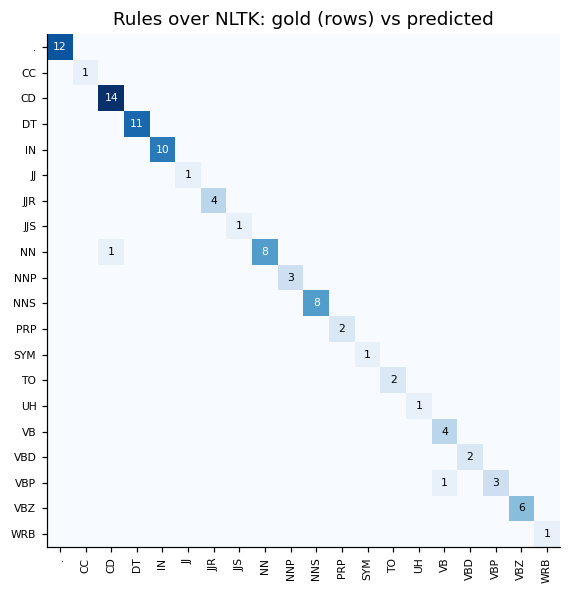

In [19]:
display(table(pos["accuracy"]))
display(table(pos["table_d"]))
import numpy as np
cm = np.array(pos["confusion"]["rules_nltk"]); labels = pos["labels"]
fig, ax = plt.subplots(figsize=(6.5, 5.5)); ax.imshow(cm, cmap="Blues"); ax.grid(False)
ax.set_xticks(range(len(labels)), labels, rotation=90, fontsize=7); ax.set_yticks(range(len(labels)), labels, fontsize=7)
for i in range(len(labels)):
    for j in range(len(labels)):
        if cm[i, j]: ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7, color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_title("Rules over NLTK: gold (rows) vs predicted"); plt.tight_layout(); plt.show()

The rule layer wins (97.9% vs NLTK 90.7%) because the errors are systematic: the same few words in the same positions.
The CRF learns some of them from features but still calls sentence-initial "Round" a noun — 20 domain sentences are too
few to override the Treebank. With 97 test tokens, one token is one point.

### Exercise 13 — Named entities

spaCy's model knows people, places and dates but not concepts, misconceptions, knowledge-tracing models, datasets or
metrics. An EntityRuler placed **before** the model adds those five types from `config/domain_lexicon.csv`, plus money,
ISO-date and product patterns. Both are scored against 161 hand-annotated entities in 61 sentences (exact span and type).

In [20]:
from nlp_core.ner import entities
s = "Ms. Priya Raman compared BKT and DKT on MathDial using AUC, and bought fraction tiles for Rs 2,500 on 12 August 2026."
print("model:", [(e["text"], e["label"]) for e in entities(s, False)])
print("ruler:", [(e["text"], e["label"]) for e in entities(s, True)])
ner = X.exercise13()
print({k: ner["model"]["overall"][k] for k in ("precision", "recall", "f1")}, "->", {k: ner["ruler"]["overall"][k] for k in ("precision", "recall", "f1")})
display(pd.DataFrame({t: {"model F1": ner["model"]["by_type"][t]["f1"], "ruler F1": ner["ruler"]["by_type"][t]["f1"], "gold": ner["ruler"]["by_type"][t]["gold"]} for t in ner["ruler"]["by_type"]}).T)
display(table(ner["dependency"]))
display(table(ner["table_e"]).head(25))

model: [('Priya Raman', 'PERSON'), ('BKT', 'ORG'), ('DKT', 'ORG'), ('MathDial', 'PRODUCT'), ('12 August 2026', 'DATE')]


ruler: [('Priya Raman', 'PERSON'), ('BKT', 'KT_MODEL'), ('DKT', 'KT_MODEL'), ('MathDial', 'DATASET'), ('AUC', 'METRIC'), ('fraction', 'CONCEPT'), ('Rs 2,500', 'MONEY'), ('12 August 2026', 'DATE')]


{'precision': 0.6055, 'recall': 0.4099, 'f1': 0.4889} -> {'precision': 0.8395, 'recall': 0.8447, 'f1': 0.8421}


,model F1,ruler F1,gold
CONCEPT,0.0000,1.0000,19.0
DATASET,0.0000,0.8800,13.0
DATE,0.8000,0.8387,15.0
EVENT,0.0000,0.0000,5.0
GPE,0.9412,0.9412,9.0
KT_MODEL,0.0000,1.0000,9.0
METRIC,0.0000,1.0000,8.0
MISCONCEPTION,0.0000,0.7500,4.0
MONEY,0.0000,1.0000,13.0
ORG,0.7143,0.7907,19.0


,entity,spacy_default_tokens,hybrid_tokens_model_only,hybrid_tokens_plus_ruler
0,"Rs 2,500","2,500 (CARDINAL)","2,500 (CARDINAL)","Rs 2,500 (MONEY)"
1,Rs 200,200 (CARDINAL),200 (CARDINAL),Rs 200 (MONEY)
2,"Rs 1,200","1,200 (CARDINAL)","1,200 (CARDINAL)","Rs 1,200 (MONEY)"
3,"Rs 18,000","18,000 (CARDINAL)","18,000 (CARDINAL)","Rs 18,000 (MONEY)"
4,"Rs 17,100","17,100 (CARDINAL)","17,100 (CARDINAL)","Rs 17,100 (MONEY)"
5,"$3,650","3,650 (MONEY)",missed,"$3,650 (MONEY)"
6,$50,50 (MONEY),missed,$50 (MONEY)
7,$205,205 (MONEY),missed,$205 (MONEY)
8,$30,30 (MONEY),missed,$30 (MONEY)
9,$95,95 (MONEY),missed,$95 (MONEY)


,sentence,entity,gold_type,predicted_type_model,status_model,predicted_type_ruler,status_ruler,domain_type
0,N01,Priya Raman,PERSON,PERSON,correct,PERSON,correct,False
1,N01,Greenfield Public School,ORG,ORG,correct,ORG,correct,False
2,N01,Bengaluru,GPE,GPE,correct,GPE,correct,False
3,N01,Karnataka,GPE,GPE,correct,GPE,correct,False
4,N02,3 August 2026,DATE,DATE,correct,DATE,correct,False
5,N02,28 August 2026,DATE,,missed,,missed,False
6,N03,Rohan,PERSON,GPE,incorrect,GPE,incorrect,False
7,N03,Meera,PERSON,PERSON,correct,PERSON,correct,False
8,N03,numerator,CONCEPT,,missed,CONCEPT,correct,True
9,N03,denominator,CONCEPT,,missed,CONCEPT,correct,True


The dependency table records an interaction between modules: once the hybrid tokenizer keeps `$3,650` as one token, the
statistical model (trained on its own tokens) stops recognising it, and the ruler's MONEY patterns restore it. EVENT stays
at 0 (no patterns), and PERSON is untouched by the ruler: single Indian first names are missed or mistyped.

### Exercise 14 — N-grams and collocations

Unigrams to 5-grams over the final pipeline's terms, counted within sentences. A **meaningful filter** drops n-grams that
start or end with a stop word or punctuation; plain **stop-word removal before counting** is compared with it.

,ngram,total,unique,top_ngrams_filtered
0,Unigram,136273,8931,student (1203) | teacher (1076) | number (974) | fraction (839) | answer (726) | x (654) | 2 (576) | 's (548) | tota...
1,Bigram,122601,44647,correct answer (249) | incorrect answer (225) | incorrect solution (212) | solve yes (136) | vacuum cleaner (111) | ...
2,Trigram,110772,67421,operation when student (100) | source ashlock 2006 (84) | large language model (74) | explanation the learner (72) |...
3,4-Gram,100377,71110,number operation when student (68) | smell like wet dog (63) | value of the pension (61) | large language model llm ...
4,5-Gram,91000,68465,relationship and function when student (32) | not get a second hotdog (31) | amount she have to pay (29) | take to d...


,n,dictionary_size_all,dictionary_size_filtered,dictionary_size_after_removal,invented_by_removal,singleton_share,term_dictionary
0,1,8931,8827,8827,0,0.5027,8931
1,2,44647,23327,39540,16213,0.6694,8931
2,3,67421,29339,45241,29112,0.8011,8931
3,4,71110,29968,41470,32131,0.8575,8931
4,5,68465,28262,36328,30756,0.8815,8931


,ngram,count,log_likelihood,pmi
0,correct answer,249,2289.10,7.127
1,incorrect solution,212,2013.03,7.421
2,incorrect answer,225,1857.24,6.697
3,vacuum cleaner,111,1794.51,10.362
4,solve yes,136,1469.37,8.271
5,ashlock 2006,84,1330.78,10.522
6,source ashlock,84,1111.66,9.264
7,7th grade,62,1010.91,10.909
8,wet dog,65,995.21,10.466
9,mixed number,100,941.81,7.103


,ngram,count,log_likelihood,pmi
0,out how many,32,3762.63,14.014
1,teacher how many,28,3587.79,11.305
2,calculate how many,3,3550.42,11.143
3,leave how many,7,3519.46,11.595
4,danielle how many,3,3510.23,13.025
5,gumballs how many,3,3508.26,12.539
6,pencil how many,3,3507.81,12.426
7,candle how many,4,3507.03,11.321


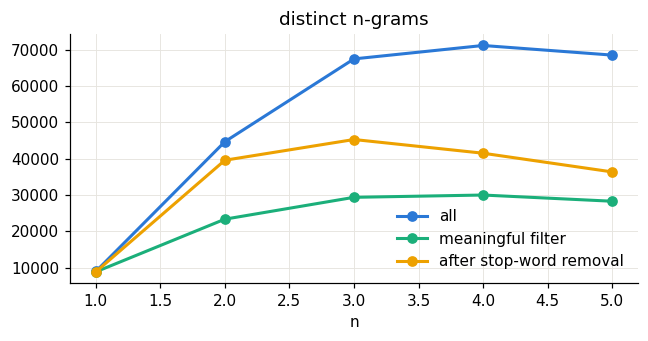

In [21]:
ng = X.exercise14(runs, FINAL)
display(table(ng["table_f"]))
display(table(ng["dictionary"]))
display(table(ng["collocations"]["bigram"]).head(12)); display(table(ng["collocations"]["trigram"]).head(8))
d = pd.DataFrame(ng["dictionary"])
fig, ax = plt.subplots(figsize=(6, 3.2))
for col, c, lab in [("dictionary_size_all", "#2a78d6", "all"), ("dictionary_size_filtered", "#1baf7a", "meaningful filter"), ("dictionary_size_after_removal", "#eda100", "after stop-word removal")]:
    ax.plot(d.n, d[col], "o-", color=c, lw=2, label=lab)
ax.set_xlabel("n"); ax.set_title("distinct n-grams"); ax.legend(frameon=False); plt.tight_layout(); plt.show()

Removing stop words first invents n-grams that never occur in the text (for bigrams, "numerator denominator" from
"the numerator and the denominator" is the most frequent). The meaningful filter avoids that, so it is the default.

---
## Module 3 — Pipeline design, comparison and justification

| Run | Tokenizer | Stop words | Normaliser | Order | Purpose |
|---|---|---|---|---|---|
| A | NLTK | NLTK | Porter | stop → stem | the brief's left branch |
| B | spaCy | none | WordNet + POS | — | the brief's right branch |
| H | hybrid | custom | spaCy lemma (in context) | lemma → stop | hybrid hypothesis, proposed before any result |
| C1 | NLTK | NLTK | Porter | stem → stop | order test (Exercise 11) |
| C2 | spaCy | none | WordNet, no POS | — | does POS matter for lemmas? |
| C3 | tiktoken cl100k | none | none | — | BPE pieces as index terms |
| H2 | hybrid | custom | WordNet context-free + compound parts | lemma → stop | **post-hoc**, designed after H's errors; not eligible |

,pipeline,tokenizer,stopwords,normalizer,order,token_count,vocabulary_size,domain_term_fidelity,meaningful_ngrams_share,precision,recall,f1,p@5,mean_query_time_ms,posthoc,selected
1,B,spacy,none,wordnet_pos,stop_then_norm,136273,8931,0.9736,0.34,0.8928,0.6200,0.6791,0.6933,0.3103,False,True
6,H2,hybrid,custom,wordnet_cf,norm_then_stop,89044,9454,0.9820,0.31,0.8817,0.6200,0.6680,0.6933,0.1548,True,False
0,A,nltk,nltk,porter,stop_then_norm,85104,8549,0.9632,0.31,0.8951,0.5977,0.6432,0.6533,0.1949,False,False
4,C2,spacy,none,wordnet_nopos,stop_then_norm,136273,9495,0.9917,0.29,0.8951,0.5977,0.6432,0.6533,0.1287,False,False
3,C1,nltk,nltk,porter,norm_then_stop,87633,8559,0.9632,0.31,0.8951,0.5977,0.6432,0.6533,0.2107,False,False
2,H,hybrid,custom,spacy,norm_then_stop,86519,9456,0.9507,0.31,0.8595,0.5533,0.6346,0.6800,3.8923,False,False
5,C3,tiktoken_cl100k,none,none,stop_then_norm,156313,7748,0.7582,0.09,0.6878,0.3891,0.4308,0.4000,0.0864,False,False


selection rule: highest mean F1, then P@5, then domain-term fidelity, then the smaller vocabulary | selected: B


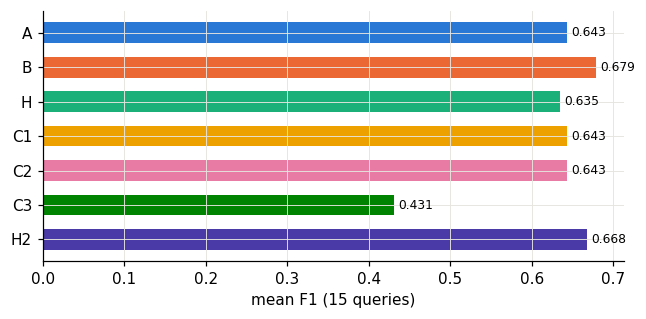

In [22]:
th = pd.DataFrame(ir["table_h"])
display(th[["pipeline", "tokenizer", "stopwords", "normalizer", "order", "token_count", "vocabulary_size", "domain_term_fidelity",
            "meaningful_ngrams_share", "precision", "recall", "f1", "p@5", "mean_query_time_ms", "posthoc", "selected"]].sort_values("f1", ascending=False))
print("selection rule:", ir["selection_rule"], "| selected:", ir["winner"])
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(th.pipeline, th.f1, color=[RUN_COLOR[p] for p in th.pipeline], height=0.6); ax.invert_yaxis(); ax.set_xlabel("mean F1 (15 queries)")
for i, v in enumerate(th.f1): ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

**Error analysis of the hypothesis.** H differs from B on one query only — Q15 (`LLM AND "knowledge tracing"`). spaCy's
lemmas depend on context: in D10 "Knowledge Tracing" is tagged as a proper noun and keeps the lemma *tracing* while the
query is lemmatized to *trace*, and "LLM-based" is a single hybrid token, so *llm* is not indexed on its own. H2 fixes
both and recovers most of the loss, but it was designed after seeing the errors and is evaluated on the same queries,
so it is reported and not selected. The hypothesis is reported as a negative result.

In [23]:
ev = pd.DataFrame(ir["evaluation"])
piv = ev.pivot(index="qid", columns="pipeline", values="f1")[["A", "B", "H", "C1", "C2", "C3", "H2"]]
display(piv.style.background_gradient(cmap="Blues", vmin=0, vmax=1).format("{:.3f}"))
display(pd.DataFrame(ir["retrieval"]).query("qid in ['Q10', 'Q15'] and pipeline in ['B', 'H', 'H2']")[["pipeline", "qid", "query", "analysed_terms", "retrieved_documents"]])

pipeline,A,B,H,C1,C2,C3,H2
qid,,,,,,,
Q01,0.933,0.933,0.933,0.933,0.933,0.333,0.933
Q02,0.833,0.833,0.833,0.833,0.833,0.250,0.833
Q03,0.909,0.909,0.909,0.909,0.909,0.857,0.909
Q04,0.500,0.500,0.500,0.500,0.500,0.500,0.500
Q05,0.200,0.571,0.571,0.200,0.200,0.000,0.571
Q06,0.571,0.571,0.571,0.571,0.571,0.222,0.571
Q07,0.923,0.923,0.923,0.923,0.923,0.923,0.923
Q08,0.500,0.500,0.500,0.500,0.500,0.000,0.500
Q09,0.526,0.526,0.526,0.526,0.526,0.000,0.526


,pipeline,qid,query,analysed_terms,retrieved_documents
24,B,Q10,"""knowledge tracing"" AND NOT programming",knowledge trace ; NOT program,D10
29,B,Q15,"LLM AND ""knowledge tracing""",llm ; knowledge trace,D10 D09
39,H,Q10,"""knowledge tracing"" AND NOT programming",knowledge trace ; NOT program,D11
44,H,Q15,"LLM AND ""knowledge tracing""",llm ; knowledge trace,D11
99,H2,Q10,"""knowledge tracing"" AND NOT programming",knowledge trace ; NOT program,D10
104,H2,Q15,"LLM AND ""knowledge tracing""",llm ; knowledge trace,D10 D11 D09


### Justification of the final pipeline

| Stage | Decision | Evidence from this run |
|---|---|---|
| Extraction | pdfplumber, trafilatura, MathML → a/b | fewer broken words; no boilerplate |
| Cleaning | vulgar fractions before NFKC; digit-word glue | keeps 3½ = 3 1/2 |
| Tokenization | spaCy tokens for B; hybrid for the linguistic branch | hybrid gold F1 0.996 vs NLTK 0.949 |
| Stop words | none for retrieval | no query depends on a stop word; standard lists delete *not, more, than* |
| Normalisation | WordNet lemmas with POS | 98.2% lemma accuracy vs 86.8% without POS; no over-stemming |
| Index terms | pipeline B | highest mean F1 under the fixed rule |

Each page of the website carries the same four questions (why, where, depends, if moved) for its step.

---
## Module 4 — Positional inverted index

Each term maps to the documents containing it and the positions where it occurs. A sentence end leaves a one-position
gap, so phrases never match across sentences. Ranking uses tf-idf = (1 + log₁₀ tf) × log₁₀(N / df), summed over the
query's non-negated terms; ties go to the lower document id so P@K is reproducible.

In [24]:
final = runs[FINAL]; idx = final.index
print(f"pipeline {FINAL}: {idx.vocabulary:,} terms, {idx.N} documents, {sum(len(p) for p in idx.postings.values()):,} postings")
an = final.pipeline.analyzer()
for w in ["denominators", "misconception", "tracing"]:
    t = an(w)[0][0]
    post = sorted(idx.postings.get(t, {}).items(), key=lambda x: -len(x[1]))[:5]
    print(f"{w!r} -> {t!r}: df={idx.df(t)} idf={idx.idf(t):.3f} top postings", [(d, len(p), p[:4]) for d, p in post])
print("inverted_index.json:", (RESULTS / "inverted_index.json").stat().st_size // 1024, "KB")

pipeline B: 8,931 terms, 30 documents, 20,083 postings
'denominators' -> 'denominator': df=15 idf=0.301 top postings [('D04', 114, [6, 26, 46, 128]), ('D16', 46, [1969, 1999, 2030, 2060]), ('D08', 40, [192, 217, 687, 711]), ('D01', 35, [357, 374, 402, 489]), ('D02', 33, [188, 202, 238, 371])]
'misconception' -> 'misconception': df=10 idf=0.477 top postings [('D16', 221, [0, 50, 100, 150]), ('D15', 28, [3, 23, 54, 76]), ('D09', 3, [79, 3304, 3378]), ('D12', 3, [4528, 4607, 4618]), ('D11', 2, [2853, 3585])]
'tracing' -> 'trace': df=3 idf=1.000 top postings [('D10', 3, [270, 1515, 5250]), ('D11', 2, [5203, 5481]), ('D09', 1, [114])]
inverted_index.json: 1390 KB


---
## Module 5 — Query processing and search

Operators are upper-case only (AND, OR, NOT) because lower-case *not* and *and* are ordinary words in this domain
("not a common denominator"). Runs of words and quoted strings are phrase units; adjacent units get an implicit AND;
brackets group; precedence is NOT > AND > OR; NOT is the complement within the collection. The expression goes through
a shunting-yard parser to postfix and is evaluated with set operations.

In [25]:
from nlp_core.query import lex, to_postfix, classify
for q in ['dialogue AND (tutor OR teacher)', 'LCD OR "least common denominator"', 'denominator AND NOT common', 'fraction "common denominator"']:
    print(f"{q:38} lex={lex(q)}\n{'':38} postfix={to_postfix(lex(q))}  type={classify(q)}")
eng = final.engine()
for q in ["common denominator", "fraction AND misconception", "denominator AND NOT common"]:
    r = eng.search(q, repeats=5)
    print(f"{q:30} {r['type']:18} {r['count']:>2} docs in {r['time_ms']:.3f} ms  top: {[d for d, _ in r['results'][:5]]}")

dialogue AND (tutor OR teacher)        lex=['dialogue', 'AND', '(', 'tutor', 'OR', 'teacher', ')']
                                       postfix=['dialogue', 'tutor', 'teacher', 'OR', 'AND']  type=Advanced Boolean
LCD OR "least common denominator"      lex=['LCD', 'OR', '"least common denominator"']
                                       postfix=['LCD', '"least common denominator"', 'OR']  type=Boolean OR
denominator AND NOT common             lex=['denominator', 'AND', 'NOT', 'common']
                                       postfix=['denominator', 'common', 'NOT', 'AND']  type=Boolean NOT
fraction "common denominator"          lex=['fraction', 'AND', '"common denominator"']
                                       postfix=['fraction', '"common denominator"', 'AND']  type=Phrase (trigram)
common denominator             Phrase (bigram)    11 docs in 0.317 ms  top: ['D04', 'D03', 'D16', 'D07', 'D05']
fraction AND misconception     Boolean AND         6 docs in 0.317 ms  top: ['D16', 'D15'

In [26]:
qs = pd.DataFrame(X.queries())
display(qs)
display(pd.DataFrame(ir["retrieval"]).query("pipeline == @FINAL")[["qid", "query", "type", "analysed_terms", "results", "retrieved_documents", "time_ms"]])

,qid,query,information_need,n_relevant
0,Q01,denominator,"Documents that explain, practise or show learners reasoning explicitly about denominators.",15
1,Q02,misconception,"Documents that identify, describe or study students' misconceptions (systematic misunderstandings).",14
2,Q03,common denominator,Documents that explain or apply finding and using a common denominator.,11
3,Q04,knowledge tracing model,Documents describing knowledge tracing models (estimating or predicting student knowledge over time).,3
4,Q05,added the numerators,"Documents where adding numerators (with or without adding denominators) is described, as the correct procedure or as...",9
5,Q06,fraction AND misconception,Documents about misconceptions specifically concerning fractions.,8
6,Q07,"LCD OR ""least common denominator""",Documents that explain or use the least common denominator.,7
7,Q08,denominator AND NOT common,"Documents about denominators in contexts OTHER than finding a common denominator (meaning of the denominator, multip...",6
8,Q09,dialogue AND (tutor OR teacher),Documents that contain or study tutoring or classroom dialogue between teachers or tutors and students.,14
9,Q10,"""knowledge tracing"" AND NOT programming",Knowledge tracing research outside programming education.,2


,qid,query,type,analysed_terms,results,retrieved_documents,time_ms
15,Q01,denominator,Keyword (unigram),denominator,15,D04 D16 D08 D01 D02 D03 D07 D05 D25 D27 D29 D26 D06 D13 D28,0.2109
16,Q02,misconception,Keyword (unigram),misconception,10,D16 D15 D09 D12 D11 D29 D14 D17 D18 D27,0.1855
17,Q03,common denominator,Phrase (bigram),common denominator,11,D04 D03 D16 D07 D05 D25 D29 D27 D26 D13 D28,0.2573
18,Q04,knowledge tracing model,Phrase (trigram),knowledge trace model,1,D09,0.3033
19,Q05,added the numerators,Phrase (trigram),add the numerator,5,D16 D04 D03 D01 D25,0.5770
20,Q06,fraction AND misconception,Boolean AND,fraction ; misconception,6,D16 D15 D29 D27 D17 D18,0.2672
21,Q07,"LCD OR ""least common denominator""",Boolean OR,lcd ; least common denominator,6,D04 D16 D25 D27 D07 D26,0.4013
22,Q08,denominator AND NOT common,Boolean NOT,denominator ; NOT common,2,D01 D06,0.1787
23,Q09,dialogue AND (tutor OR teacher),Advanced Boolean,dialogue ; tutor ; teacher,5,D11 D12 D09 D14 D10,0.4094
24,Q10,"""knowledge tracing"" AND NOT programming",Boolean NOT,knowledge trace ; NOT program,1,D10,0.3630


---
## Module 6 — Evaluation

Fifteen queries with written information needs, judged against all 30 documents (450 judgements). Set metrics (P, R, F1)
score the Boolean result; P@K, R@K and average precision score its tf-idf order.

,pipeline,label,precision,recall,f1,p@3,p@5,p@10,r@3,r@5,r@10,ap,mean_query_time_ms,index_seconds
1,B,Pipeline B,0.8928,0.6200,0.6791,0.7778,0.6933,0.5133,0.3394,0.4476,0.5910,0.6115,0.3103,1.18
6,H2,"H2: hybrid, revised (post-hoc)",0.8817,0.6200,0.6680,0.7778,0.6933,0.5133,0.3394,0.4476,0.5910,0.6115,0.1548,4.34
0,A,Pipeline A,0.8951,0.5977,0.6432,0.7333,0.6533,0.4933,0.3245,0.4254,0.5688,0.5908,0.1949,1.07
4,C2,C2 no-POS lemma,0.8951,0.5977,0.6432,0.7333,0.6533,0.4933,0.3245,0.4254,0.5688,0.5908,0.1287,1.26
3,C1,C1 order test,0.8951,0.5977,0.6432,0.7333,0.6533,0.4933,0.3245,0.4254,0.5688,0.5908,0.2107,0.81
2,H,H: hybrid hypothesis,0.8595,0.5533,0.6346,0.7556,0.6800,0.5067,0.2727,0.3809,0.5243,0.5449,3.8923,1.16
5,C3,C3 BPE index,0.6878,0.3891,0.4308,0.4889,0.4000,0.2867,0.2461,0.3023,0.3840,0.3885,0.0864,1.44


,qid,query,retrieved,relevant,hits,precision,recall,f1,p@5,r@5,ap
15,Q01,denominator,15,15,14,0.9333,0.9333,0.9333,1.0,0.3333,0.9289
16,Q02,misconception,10,14,10,1.0000,0.7143,0.8333,1.0,0.3571,0.7143
17,Q03,common denominator,11,11,10,0.9091,0.9091,0.9091,1.0,0.4545,0.9008
18,Q04,knowledge tracing model,1,3,1,1.0000,0.3333,0.5000,0.2,0.3333,0.3333
19,Q05,added the numerators,5,9,4,0.8000,0.4444,0.5714,0.8,0.4444,0.4222
20,Q06,fraction AND misconception,6,8,4,0.6667,0.5000,0.5714,0.8,0.5000,0.5000
21,Q07,"LCD OR ""least common denominator""",6,7,6,1.0000,0.8571,0.9231,1.0,0.7143,0.8571
22,Q08,denominator AND NOT common,2,6,2,1.0000,0.3333,0.5000,0.4,0.3333,0.3333
23,Q09,dialogue AND (tutor OR teacher),5,14,5,1.0000,0.3571,0.5263,1.0,0.3571,0.3571
24,Q10,"""knowledge tracing"" AND NOT programming",1,2,1,1.0000,0.5000,0.6667,0.2,0.5000,0.5000


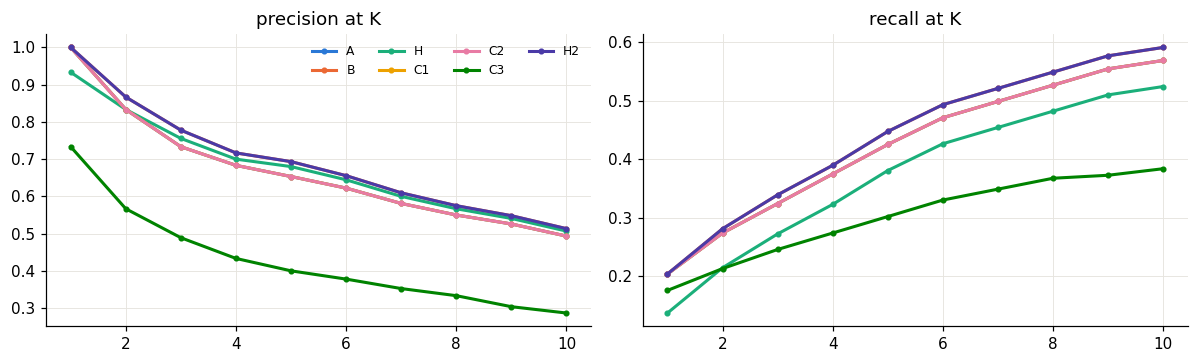

In [27]:
display(pd.DataFrame(ir["overall"]).sort_values("f1", ascending=False))
display(ev.query("pipeline == @FINAL")[["qid", "query", "retrieved", "relevant", "hits", "precision", "recall", "f1", "p@5", "r@5", "ap"]])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for run, pts in ir["curves"].items():
    k = [p["k"] for p in pts]
    ax[0].plot(k, [p["p"] for p in pts], "o-", ms=3, lw=2, color=RUN_COLOR[run], label=run)
    ax[1].plot(k, [p["r"] for p in pts], "o-", ms=3, lw=2, color=RUN_COLOR[run], label=run)
ax[0].set_title("precision at K"); ax[1].set_title("recall at K"); ax[0].legend(frameon=False, ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

Low-recall queries show the vocabulary gap the research must bridge: Q12 `"student explanation"` misses documents that
contain explanations without naming them, and Q09 misses transcripts that never use the word *dialogue*. Exact-match
retrieval cannot close that gap; it is a motivation for the semantic grounding in the research phase.

**Relevance judgements.** `gold/qrels.csv` was drafted with an AI assistant from the information needs and must be
reviewed. `gold/qrels_second_judge_template.csv` lists a stratified sample to judge blind; Cohen's kappa between the two
judges is computed below once it is filled in.

In [28]:
from nlp_core.evaluate import cohen_kappa
import csv
tmpl = GOLD / "qrels_second_judge_template.csv"
rows = list(csv.DictReader(open(tmpl))) if tmpl.exists() else []
done = [r for r in rows if r.get("second_judge", "").strip() in ("0", "1")]
if done:
    first = {(r["qid"], r["doc_id"]): r["relevant"] for r in csv.DictReader(open(GOLD / "qrels.csv"))}
    k = cohen_kappa([first[(r["qid"], r["doc_id"])] for r in done], [r["second_judge"] for r in done])
    print(f"Cohen's kappa on {len(done)} double-judged pairs: {k:.3f}")
else:
    print(f"{len(rows)} pairs waiting for a second judge in {tmpl.name}; kappa is computed here once they are filled in.")

87 pairs waiting for a second judge in qrels_second_judge_template.csv; kappa is computed here once they are filled in.


---
## Scale tier — the full MathDial and TalkMoves collections

All exercises and relevance judgements use the 30-document corpus. To show the pipeline holds at scale, the full
MathDial (2,861 dialogues) and TalkMoves (566 transcripts) collections — 3.4 million words — were cleaned, tokenized and
indexed with pipelines A, B and H2 by `scripts/run_scale.py` (about eight minutes). The results are loaded here.

In [29]:
sc = json.loads((RESULTS / "app" / "scale.json").read_text())
display(pd.DataFrame(sc["summary"])); display(pd.DataFrame(sc["pipelines"])); display(pd.DataFrame(sc["bpe"]))
sp = sc["collections"]["talkmoves"]["speakers"]
print({k: {x: v[x] for x in ("turns", "words", "mean_turn_length")} for k, v in sp.items()})
print("student bigrams:", [b["ngram"] for b in sp["student"]["bigrams"][:8]])
print("teacher bigrams:", [b["ngram"] for b in sp["teacher"]["bigrams"][:8]])

,collection,documents,characters,estimated_sentences,tokens_whitespace,index_terms_B
0,mathdial,2861,7399005,112394,1386905,1405561
1,talkmoves,566,10768592,213629,2009857,2052184


,collection,pipeline,index_terms,vocabulary,build_seconds,index_json_mb,median_query_ms
0,mathdial,A,832525,9893,39.6,7.60,0.393
1,mathdial,B,1405561,9640,83.5,11.73,0.484
2,mathdial,H2,862029,10970,45.2,7.92,0.420
3,talkmoves,A,1095842,11334,57.7,9.06,0.505
4,talkmoves,B,2052184,13123,115.3,15.13,0.762
5,talkmoves,H2,1112808,12153,69.5,9.19,0.617


,method,vocabulary_size,tokens_estimate,tokens_per_word
0,"our byte-level BPE, vocab 2000",2000,4918700,1.429
1,"our byte-level BPE, vocab 8000",8000,4276820,1.243
2,"our byte-level BPE, vocab 32000",32000,4156930,1.208
3,tiktoken gpt2,50257,4479650,1.302
4,tiktoken cl100k_base,100277,4382910,1.274
5,tiktoken o200k_base,200019,4358000,1.266


{'student': {'turns': 58926, 'words': 351517, 'mean_turn_length': 5.97}, 'teacher': {'turns': 173846, 'words': 1424887, 'mean_turn_length': 8.2}}
student bigrams: ['dont know', 'one half', 'two thirds', 'all right', 'one third', 'three times', 'times two', 'one two']
teacher bigrams: ['all right', 'im going', 'youre going', 'make sure', 'little bit', 'would like', 'go ahead', 'figure out']


---
## Preview — from a learner sentence to a candidate evidence record

This is where the assessment hands over to the research. The record bundles the observation, what the pipeline
extracted (tokens, numbers and expressions, concepts, verb–object pairs), transparent detectors that check the arithmetic,
and the nearest misconception descriptions retrieved by tf-idf from MaE (real) and the malrules (synthetic). It is marked
as a prototype for human review; no learner model or probability is computed.

In [30]:
from nlp_core.evidence import evidence_record
rec = evidence_record("I did 1/2 + 1/3 = 2/5 because you add the tops and then add the bottoms.")
print(json.dumps({k: rec[k] for k in ("evidence_id", "status")}, indent=1))
print("detectors:", [(d["hypothesis"], d["check"]) for d in rec["interpretation"]["detectors"]])
print("grounding:", [(g["id"], g["name"][:50], g["score"]) for g in rec["interpretation"]["retrieved_grounding"][:3]])

{
 "evidence_id": "E_dee53545dc",
 "status": "PROTOTYPE - candidate evidence, not a diagnosis"
}
detectors: [('M01 adds numerators and adds denominators', '2/5 = (1+1)/(2+3); correct sum is 5/6'), ('M01 adds numerators and adds denominators', 'verbal description')]
grounding: [('M01', 'Adds numerators and adds denominators', 0.4226), ('M09', 'Misreads mixed numbers', 0.1351), ('MaE09', 'when students find common denominators but wrongly', 0.1189)]


## Results files

In [31]:
required = ["preprocessing_results.csv", "tokenization_comparison.csv", "stemming_lemmatization.csv", "pos_tagging_results.csv",
            "ner_results.csv", "unigram_results.csv", "bigram_results.csv", "trigram_results.csv", "ngram_results.csv",
            "bpe_results.csv", "pipeline_comparison.csv", "retrieval_results.csv", "evaluation_results.csv", "inverted_index.json"]
display(pd.DataFrame([{"file": f, "present": (RESULTS / f).exists(), "KB": round((RESULTS / f).stat().st_size / 1024, 1)} for f in required]))
print(len(list(RESULTS.glob("*.*"))), "files in results/ in total")

,file,present,KB
0,preprocessing_results.csv,True,0.2
1,tokenization_comparison.csv,True,5.9
2,stemming_lemmatization.csv,True,2.1
3,pos_tagging_results.csv,True,0.6
4,ner_results.csv,True,9.2
5,unigram_results.csv,True,1.4
6,bigram_results.csv,True,1.7
7,trigram_results.csv,True,1.8
8,ngram_results.csv,True,5.3
9,bpe_results.csv,True,5.5


40 files in results/ in total


## Conclusion

The selected pipeline B (spaCy tokens, no stop-word removal, WordNet lemmas with POS) reaches mean F1 0.679 on the 15
gold queries under a rule fixed in advance. The hybrid hypothesis H scored 0.635 and is reported as a negative result;
its post-hoc repair H2 (0.668) is labelled and not eligible. The domain work that carried the most weight was elsewhere:
the hybrid tokenizer (gold F1 0.996), the custom stop list that keeps *not, more, than*, the POS rule layer (97.9%) and
the EntityRuler (NER F1 0.49 → 0.84). The remaining recall gap on explanation-style queries is the motivation for the
semantic, learner-state work of the research phase.